In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
iv=pd.read_csv("./fct_invoice.csv") #iv = invoice
cd=pd.read_json("./dim_customer.json") #cd = customer data

In [9]:
iv

,invoice_no,customer_id,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,229,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,3433,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,644,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,4900,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,1089,Books,4,60.60,Cash,24/10/2021,Kanyon
...,...,...,...,...,...,...,...,...
99452,I219422,2344,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,172,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,425,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,577,Technology,4,4200.00,Cash,16/03/2021,Istinye Park


# Easy

### 1. How many unique customers are in the dataset?

In [15]:
unique_customers = iv['customer_id'].nunique()
print(f'There are {unique_customers} unique customers in the dataset.')

There are 5191 unique customers in the dataset.


### 2. What are the different categories of products available? How many unique categories are there?

In [18]:
#sort the category field 
#len the output of the sorted category field 

available_categories = iv['category'].unique().tolist()
unique_categories = iv['category'].nunique()

print(f'Available Categories: {available_categories}')
print(f'No. of Unique Categories: {unique_categories}')

Available Categories: ['Clothing', 'Shoes', 'Books', 'Cosmetics', 'Food & Beverage', 'Toys', 'Technology', 'Souvenir']
No. of Unique Categories: 8


### 3. Which payment method is most popular? How many times was it used?

In [21]:
#sort by payment method, count payment method (option 1, this was discussed in class)
#pandas has a mode function (value_counts lists down the mode with the frequency)

most_popular = iv['payment_method'].mode().iloc[0]
frequency = iv['payment_method'].value_counts().head(1).iloc[0]

print(f'The most popular payment method is {most_popular} and it was used {frequency} times.')

The most popular payment method is Cash and it was used 44447 times.


# Medium

### 1. What are the three most popular categories, by total sales?

In [25]:
iv['total_sales'] = iv['quantity']*iv['price']

In [27]:
iv.head(2)

#test to see if the new column appeared

,invoice_no,customer_id,category,quantity,price,payment_method,invoice_date,shopping_mall,total_sales
0,I138884,229,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00
1,I317333,3433,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53


In [63]:
popu_by_sales = iv.groupby(by=['category']).sum()['total_sales'].nlargest(3).index.tolist()

print(f'The three most popular categories by total sales are: {popu_by_sales}')

The three most popular categories by total sales are: ['Clothing', 'Shoes', 'Technology']


### 2. What are the total sales attributed to customers over the age of 45?

In [65]:
#merging the two data frames
customer_invoice = pd.merge(iv, cd, left_on='customer_id', right_on='id')

#calculating the total sales (create new column)
customer_invoice['total_sales'] = customer_invoice['price']*customer_invoice['quantity']

In [67]:
#test to see data visualization

customer_invoice.head(2)

,invoice_no,customer_id,category,quantity,price,payment_method,invoice_date,shopping_mall,total_sales,age,first_name,gender,id,last_name,decades
0,I138884,229,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00,NaN,William,M,229,Anderson,NaN
1,I126377,229,Cosmetics,2,81.32,Credit Card,5/4/2021,Metrocity,162.64,NaN,William,M,229,Anderson,NaN


In [69]:
#getting the sum of total sales attributed to customers over the age of 45 

sales_above_45 = customer_invoice.loc[customer_invoice['age']>45, 'total_sales'].sum()
print(f' The total sales attributed to customers over the age of 45 is: {sales_above_45}')

 The total sales attributed to customers over the age of 45 is: 82039768.15


### 3. How is the data distributed across different invoice dates? Are there any seasonal trends or patterns? (Use a graph for this.)

In [71]:
customer_invoice['datetime'] = pd.to_datetime(customer_invoice['invoice_date'], format='%d/%m/%Y')
customer_invoice.head(2)

,invoice_no,customer_id,category,quantity,price,payment_method,invoice_date,shopping_mall,total_sales,age,first_name,gender,id,last_name,decades,datetime
0,I138884,229,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00,NaN,William,M,229,Anderson,NaN,2022-08-05
1,I126377,229,Cosmetics,2,81.32,Credit Card,5/4/2021,Metrocity,162.64,NaN,William,M,229,Anderson,NaN,2021-04-05


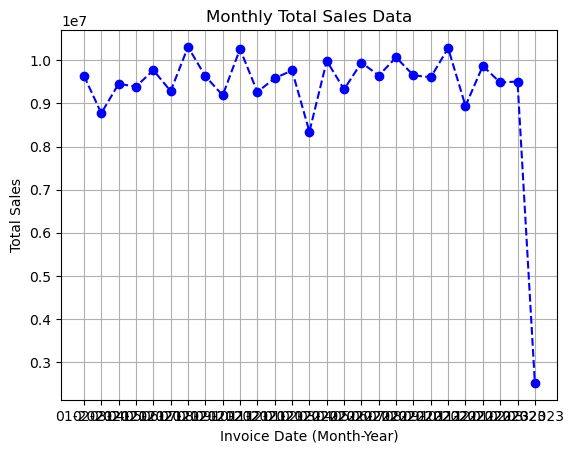

There are no seasonal trends observed. However, there was a huge decrease in monthly total sales for March 2023.
01-2021     9641614.62
02-2021     8772315.22
03-2021     9455359.38
04-2021     9389541.54
05-2021     9771756.97
06-2021     9286271.35
07-2021    10311119.68
08-2021     9630655.70
09-2021     9188165.62
10-2021    10263015.06
11-2021     9265555.29
12-2021     9585200.16
01-2022     9764311.14
02-2022     8344111.92
03-2022     9986685.16
04-2022     9326144.44
05-2022     9947574.13
06-2022     9647503.95
07-2022    10067602.95
08-2022     9651705.59
09-2022     9607629.29
10-2022    10282075.37
11-2022     8941584.66
12-2022     9869885.48
01-2023     9485599.83
02-2023     9508662.96
03-2023     2514146.79
Name: total_sales, dtype: float64


In [73]:
#Data - Plot a graph of the monthly sales  

#sum the total sales per month and year 
total_monthly_sales = customer_invoice.groupby([customer_invoice['datetime'].dt.year, customer_invoice['datetime'].dt.month])['total_sales'].sum()
total_monthly_sales.index = total_monthly_sales.index.map('{0[1]:02d}-{0[0]}'.format)
x = total_monthly_sales.index.tolist()
y = total_monthly_sales.values.tolist()

fig, ax = plt.subplots()
ax.set_xlabel('Invoice Date (Month-Year)')
ax.set_ylabel('Total Sales')
ax.set_title('Monthly Total Sales Data')

ax.plot(x,y, color = 'blue', linestyle='--', marker = "o")

plt.grid()
plt.show()

print('There are no seasonal trends observed. However, there was a huge decrease in monthly total sales for March 2023.')
print(total_monthly_sales)

# Hard

### 1. Create a pivot table showing the breakdown of sales across these dimensions, in this order: category, decade age range (e.g., 10-19, 20-29, and so forth).

In [77]:
cd['decades'] = (cd['age']//10)*10
pivot_data = iv.merge(cd[['id', 'decades']], left_on = 'customer_id', right_on = 'id')
pivot_table = pd.pivot_table(pivot_data, 
                             values = 'total_sales',
                             index = 'category',
                             columns = 'decades',
                             aggfunc = 'sum',
                             fill_value = 0,)

pivot_table.columns = pivot_table.columns.astype(int)
age_groups = {decade: f"{decade}-{decade+9}" for decade in pivot_table.columns}
pivot_table.rename(columns=age_groups, inplace=True)

print(pivot_table)

decades               10-19        20-29        30-39        40-49  \
category                                                             
Books              12801.75     79461.75     84143.10     87203.40   
Clothing         1927413.84  10250732.80  11354126.96  11215189.92   
Cosmetics         109619.36    605915.32    723544.70    665034.96   
Food & Beverage    13582.31     73491.96     87246.86     89553.29   
Shoes             993281.35   5924878.24   7200839.66   7025590.02   
Souvenir           12375.15     54943.32     64092.72     66391.80   
Technology       1129800.00   5261550.00   6159300.00   5954550.00   
Toys               60426.24    385100.80    420582.40    390906.88   

decades                50-59        60-69       70-79       80-89  
category                                                           
Books               74962.20     80476.80    54827.85    26664.00  
Clothing         10321851.76  10660642.08  7769371.28  4493698.00  
Cosmetics          587780.9